# 08 — Closure Risk Model
Classification model to identify factories at highest closure risk.
Framed as risk profiling, not forecasting — no time dimension in the data.
355 factories, ~52 closed examples (class imbalance acknowledged).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/brick_with_tiers.csv')

print(f"Dataset: {df.shape}")
print(f"\nStatus distribution:")
print(df['Status'].value_counts())
print(f"\nClass balance:")
closed = (df['Status'] != 'Running').sum()
running = (df['Status'] == 'Running').sum()
print(f"Running: {running} ({running/len(df)*100:.1f}%)")
print(f"Closed: {closed} ({closed/len(df)*100:.1f}%)")

Dataset: (355, 21)

Status distribution:
Status
Running               303
Permanently Closed     26
Temporarily Closed     26
Name: count, dtype: int64

Class balance:
Running: 303 (85.4%)
Closed: 52 (14.6%)


In [3]:
# Binary target: 1 = closed (any type), 0 = running
df['target'] = (df['Status'] != 'Running').astype(int)

# Encode categorical features
features = {
    'Machine Type': {'Hand Made': 1, 
                     'Semi Automatic Concrete Machine Made': 2,
                     'Fully Automatic Machine Made': 3, 
                     'Unknown': 0},
    'Product Type': {'Fired Clay Brick': 1, 
                     'Fly Ash Brick': 2,
                     'Unknown': 0,
                     'Fired Clay Brick, Fly Ash Brick': 1},
    'Company Size': {'Small': 1, 'Moderate': 2, 'Large': 3, 'Unknown': 0},
}

df['machine_encoded'] = df['Machine Type'].map(features['Machine Type']).fillna(0)
df['product_encoded'] = df['Product Type'].map(features['Product Type']).fillna(0)
df['size_encoded'] = df['Company Size'].map(features['Company Size']).fillna(0)

# Feature matrix
feature_cols = [
    'machine_encoded', 
    'product_encoded', 
    'size_encoded',
    'has_website',
    'has_contact',
    'is_eco',
    'modernization_score',
    'size_score'
]

X = df[feature_cols].astype(float)
y = df['target']

print(f"Features: {feature_cols}")
print(f"X shape: {X.shape}")
print(f"Closed rate: {y.mean()*100:.1f}%")

Features: ['machine_encoded', 'product_encoded', 'size_encoded', 'has_website', 'has_contact', 'is_eco', 'modernization_score', 'size_score']
X shape: (355, 8)
Closed rate: 14.6%


In [4]:
# Stratified cross-validation — respects class imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42))
])

lr_results = cross_validate(
    lr_pipeline, X, y, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=False
)

print("=== LOGISTIC REGRESSION (5-fold stratified CV) ===")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = lr_results[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

=== LOGISTIC REGRESSION (5-fold stratified CV) ===
accuracy    : 0.735 ± 0.023
precision   : 0.312 ± 0.018
recall      : 0.671 ± 0.086
f1          : 0.425 ± 0.031


In [5]:
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced',
        random_state=42
    ))
])

rf_results = cross_validate(
    rf_pipeline, X, y, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=False
)

print("=== RANDOM FOREST (5-fold stratified CV) ===")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = rf_results[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

=== RANDOM FOREST (5-fold stratified CV) ===
accuracy    : 0.741 ± 0.032
precision   : 0.314 ± 0.033
recall      : 0.635 ± 0.093
f1          : 0.417 ± 0.036


=== FEATURE IMPORTANCE ===
            feature  importance
       size_encoded    0.240503
         size_score    0.156890
        has_contact    0.145536
    product_encoded    0.136320
    machine_encoded    0.103999
modernization_score    0.088266
        has_website    0.076893
             is_eco    0.051595


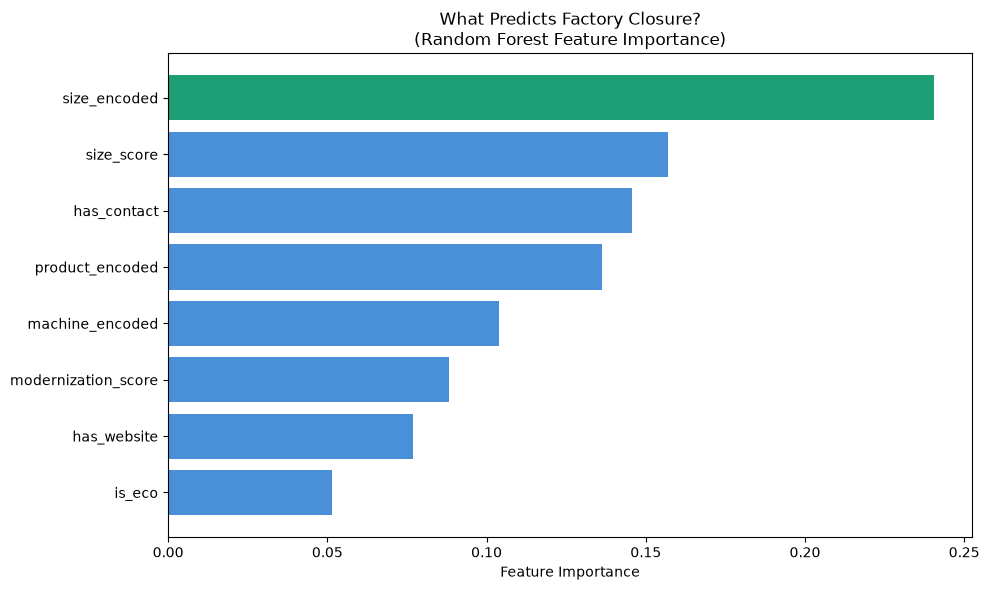

Chart saved ✓


In [6]:
# Train on full dataset for feature importance
rf_full = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',
    random_state=42
)
rf_full.fit(X, y)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_full.feature_importances_
}).sort_values('importance', ascending=False)

print("=== FEATURE IMPORTANCE ===")
print(importance_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1D9E75' if i == 0 else '#4A90D9' 
          for i in range(len(importance_df))]
ax.barh(importance_df['feature'], 
        importance_df['importance'],
        color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('What Predicts Factory Closure?\n(Random Forest Feature Importance)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/closure_risk_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

In [7]:
# Assign risk scores to all factories
df['closure_risk_score'] = rf_full.predict_proba(X)[:, 1]
df['risk_category'] = pd.cut(
    df['closure_risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("=== RISK CATEGORY DISTRIBUTION ===")
print(df['risk_category'].value_counts())

print("\n=== HIGH RISK FACTORIES (top 20) ===")
high_risk = df[df['risk_category']=='High Risk'].sort_values(
    'closure_risk_score', ascending=False
)[['Company Name', 'Districts', 'Machine Type', 
   'Product Type', 'Status', 'closure_risk_score']].head(20)
print(high_risk.to_string(index=False))

=== RISK CATEGORY DISTRIBUTION ===
risk_category
Medium Risk    133
High Risk       79
Low Risk        69
Name: count, dtype: int64

=== HIGH RISK FACTORIES (top 20) ===
                         Company Name              Districts                         Machine Type  Product Type             Status  closure_risk_score
                        Ramesh Bricks   Bhadradri Kothagudem                            Hand Made       Unknown Permanently Closed            0.986731
      Interlocking Bricks Mahabubabad            Mahabubabad         Fully Automatic Machine Made Fly Ash Brick Permanently Closed            0.984286
                   Kunchavelli Bricks Kumuram Bheem Asifabad                              Unknown       Unknown Permanently Closed            0.977333
                           NJN Bricks               Warangal                              Unknown       Unknown Permanently Closed            0.944835
                           BBI BRICKS             Peddapalli               

In [8]:
df.to_csv('../data/processed/brick_with_risk_scores.csv', index=False)
print("Exported ✓")

print("\n=== PHASE 9 SUMMARY ===")
print(f"Model: Random Forest, 5-fold stratified CV")
print(f"Most predictive feature: {importance_df.iloc[0]['feature']}")
print(f"Second most predictive: {importance_df.iloc[1]['feature']}")
print(f"High risk factories: {(df['risk_category']=='High Risk').sum()}")
print(f"Low risk factories: {(df['risk_category']=='Low Risk').sum()}")
print("\nNote: With 52 closed examples, recall is the key metric.")
print("A model that catches most closures (high recall) is more")
print("valuable than one with high accuracy but misses closures.")

Exported ✓

=== PHASE 9 SUMMARY ===
Model: Random Forest, 5-fold stratified CV
Most predictive feature: size_encoded
Second most predictive: size_score
High risk factories: 79
Low risk factories: 69

Note: With 52 closed examples, recall is the key metric.
A model that catches most closures (high recall) is more
valuable than one with high accuracy but misses closures.
